# CAD + Point Cloud + 8-View Visualizer

This notebook finds matched samples across:
- CAD code (`.py`)
- point clouds (`.npy`)
- rendered multi-view images (`view_0.png` ... `view_7.png`)

It then visualizes a couple of sample sets side-by-side.

In [2]:
from pathlib import Path
import random

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Show more lines when previewing CAD code
MAX_CODE_LINES = 80

In [3]:
# Update these paths if your dataset lives elsewhere
ROOT = Path('/home/nicksung/Desktop/nicksung/multimodel_class')
CODE_ROOT = ROOT / 'cadevolve_data' / 'CADEvolve-C' / 'CADEvolve-C-core'
PC_ROOT = ROOT / 'cadevolve_data' / 'CADEvolve-C_pointcloud' / 'CADEvolve-C' / 'CADEvolve-C-core'
IMG_ROOT = ROOT / 'cadevolve_data' / 'CADEvolve-C_image' / 'CADEvolve-C' / 'CADEvolve-C-core'

print('CODE_ROOT:', CODE_ROOT)
print('PC_ROOT:  ', PC_ROOT)
print('IMG_ROOT: ', IMG_ROOT)

CODE_ROOT: /home/nicksung/Desktop/nicksung/multimodel_class/cadevolve_data/CADEvolve-C/CADEvolve-C-core
PC_ROOT:   /home/nicksung/Desktop/nicksung/multimodel_class/cadevolve_data/CADEvolve-C_pointcloud/CADEvolve-C/CADEvolve-C-core
IMG_ROOT:  /home/nicksung/Desktop/nicksung/multimodel_class/cadevolve_data/CADEvolve-C_image/CADEvolve-C/CADEvolve-C-core


In [7]:
def image_set_complete(img_dir: Path) -> bool:
    for i in range(8):
        if not (img_dir / f'view_{i}.png').exists():
            return False
    return True

def collect_matched_samples(code_root: Path, pc_root: Path, img_root: Path):
    code_map = {p.stem: p for p in code_root.glob('*.py')}
    pc_map = {p.stem: p for p in pc_root.glob('*.npy')}

    img_map = {}
    for d in img_root.iterdir():
        if d.is_dir() and image_set_complete(d):
            img_map[d.name] = d

    common = sorted(set(code_map) & set(pc_map) & set(img_map))
    samples = [
        {
            'name': name,
            'code_path': code_map[name],
            'pc_path': pc_map[name],
            'img_dir': img_map[name],
        }
        for name in common
    ]
    return samples

samples = collect_matched_samples(CODE_ROOT, PC_ROOT, IMG_ROOT)


In [9]:
def render_point_cloud(ax, pts: np.ndarray, max_points: int = 6000):
    if pts.shape[0] > max_points:
        idx = np.random.choice(pts.shape[0], size=max_points, replace=False)
        pts = pts[idx]

    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=0.6, alpha=0.9)
    ax.set_title(f'Point Cloud (n={pts.shape[0]})')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.grid(False)

    # Keep a roughly equal aspect ratio for x/y/z
    mins = pts.min(axis=0)
    maxs = pts.max(axis=0)
    center = (mins + maxs) / 2
    radius = (maxs - mins).max() / 2
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)

def show_sample(sample: dict):
    name = sample['name']
    code_path = sample['code_path']
    pc_path = sample['pc_path']
    img_dir = sample['img_dir']

    print('=' * 120)
    print('Sample:', name)
    print('Code :', code_path)
    print('PC   :', pc_path)
    print('Image:', img_dir)

    code_text = code_path.read_text(encoding='utf-8', errors='replace')
    code_lines = code_text.splitlines()
    preview = '\n'.join(code_lines[:MAX_CODE_LINES])

    if len(code_lines) > MAX_CODE_LINES:
        preview += f'\n\n... (truncated, total lines: {len(code_lines)})'

    print('--- CAD Code Preview ---')
    print(preview)

    pts = np.load(pc_path)

    fig = plt.figure(figsize=(16, 10))
    gs = GridSpec(3, 4, figure=fig, height_ratios=[1.1, 1, 1])

    ax_pc = fig.add_subplot(gs[0, :], projection='3d')
    render_point_cloud(ax_pc, pts)

    # 8 rendered images in 2x4 layout
    for i in range(8):
        r = 1 + i // 4
        c = i % 4
        ax = fig.add_subplot(gs[r, c])
        img = plt.imread(img_dir / f'view_{i}.png')
        ax.imshow(img)
        ax.set_title(f'view_{i}')
        ax.axis('off')

    fig.suptitle(name, fontsize=12)
    plt.tight_layout()
    plt.show()

Sample: tri_prism_wave_hull_living_spoke__10_emitted_centered_scaled_binarized_centered_scaled_binarized
Code : /home/nicksung/Desktop/nicksung/multimodel_class/cadevolve_data/CADEvolve-C/CADEvolve-C-core/tri_prism_wave_hull_living_spoke__10_emitted_centered_scaled_binarized_centered_scaled_binarized.py
PC   : /home/nicksung/Desktop/nicksung/multimodel_class/cadevolve_data/CADEvolve-C_pointcloud/CADEvolve-C/CADEvolve-C-core/tri_prism_wave_hull_living_spoke__10_emitted_centered_scaled_binarized_centered_scaled_binarized.npy
Image: /home/nicksung/Desktop/nicksung/multimodel_class/cadevolve_data/CADEvolve-C_image/CADEvolve-C/CADEvolve-C-core/tri_prism_wave_hull_living_spoke__10_emitted_centered_scaled_binarized_centered_scaled_binarized
--- CAD Code Preview ---
import cadquery as cq
wp1 = cq.Workplane('XY', origin=(-14, -25, -52))
wp2 = wp1.polyline([[-86, -50], [86, -50], [0, 100]])
wp3 = wp2.close()
wp4 = wp3.extrude(102)
wp5 = cq.Workplane('XY', origin=(-14, -25, -52))
wp6 = wp5.polyli

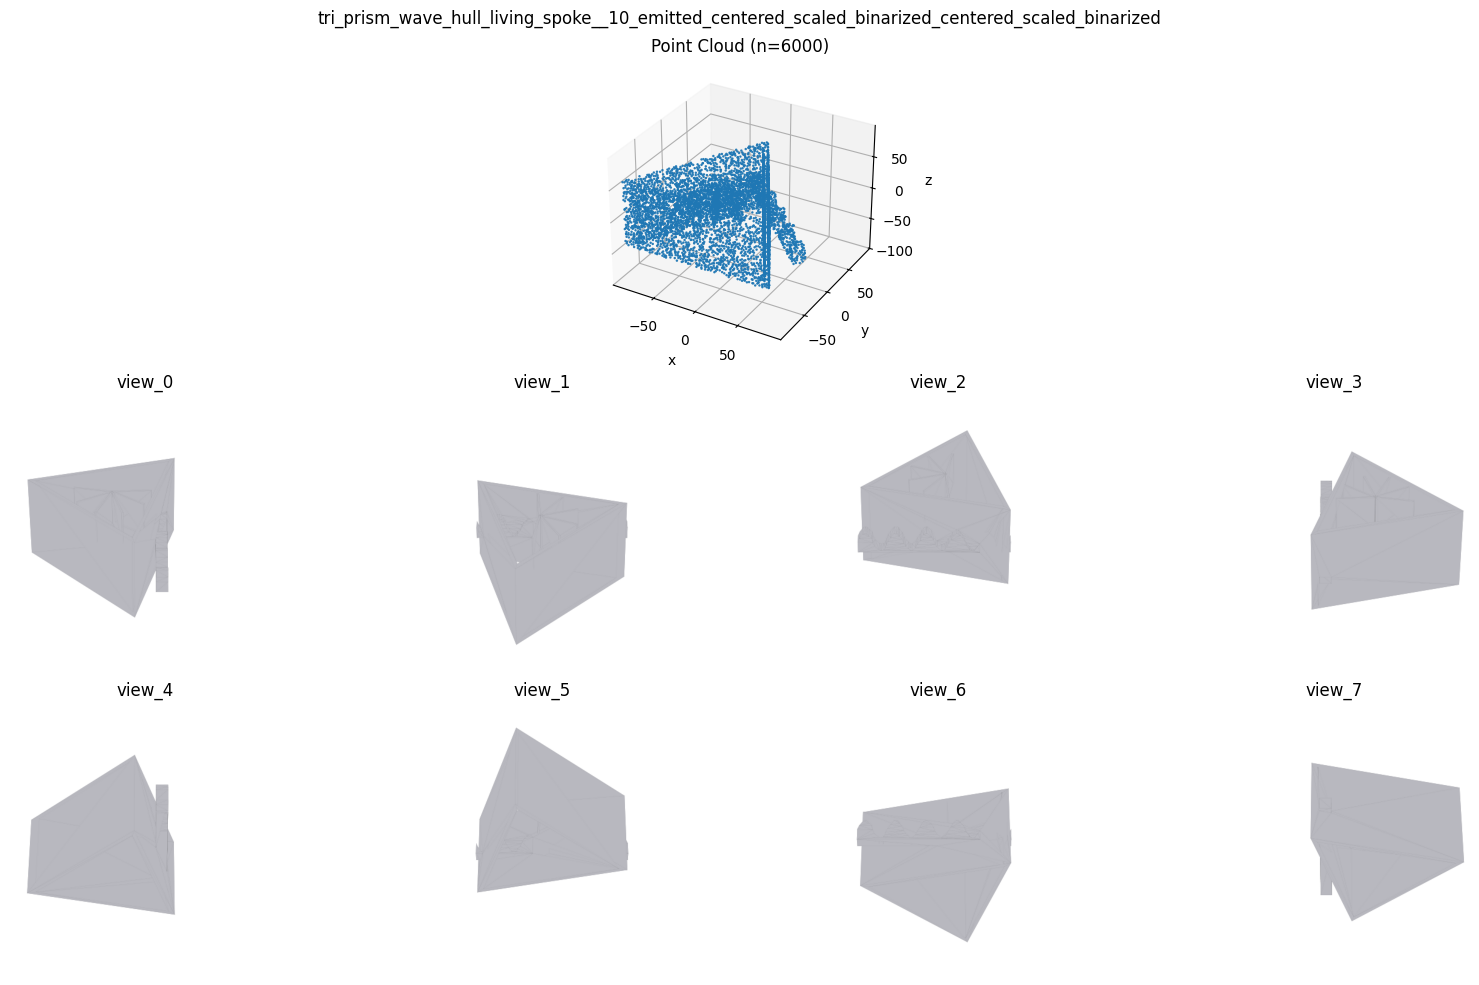

Sample: box_prism_with_twisted_cut__01_emitted_centered_scaled_binarized
Code : /home/nicksung/Desktop/nicksung/multimodel_class/cadevolve_data/CADEvolve-C/CADEvolve-C-core/box_prism_with_twisted_cut__01_emitted_centered_scaled_binarized.py
PC   : /home/nicksung/Desktop/nicksung/multimodel_class/cadevolve_data/CADEvolve-C_pointcloud/CADEvolve-C/CADEvolve-C-core/box_prism_with_twisted_cut__01_emitted_centered_scaled_binarized.npy
Image: /home/nicksung/Desktop/nicksung/multimodel_class/cadevolve_data/CADEvolve-C_image/CADEvolve-C/CADEvolve-C-core/box_prism_with_twisted_cut__01_emitted_centered_scaled_binarized
--- CAD Code Preview ---
import cadquery as cq
wp1 = cq.Workplane('XY')
wp2 = wp1.box(120, 200, 196)
wp3 = cq.Workplane('XY')
wp4 = wp3.transformed(offset=[0, 0, -98])
wp5 = wp4.polygon(8, 113)
wp6 = wp5.transformed(offset=[0, 0, 196], rotate=[0, 0, 491])
wp7 = wp6.polygon(8, 113)
wp8 = wp7.loft(combine=1, ruled=1)
wp9 = wp2.cut(wp8)
result = wp9


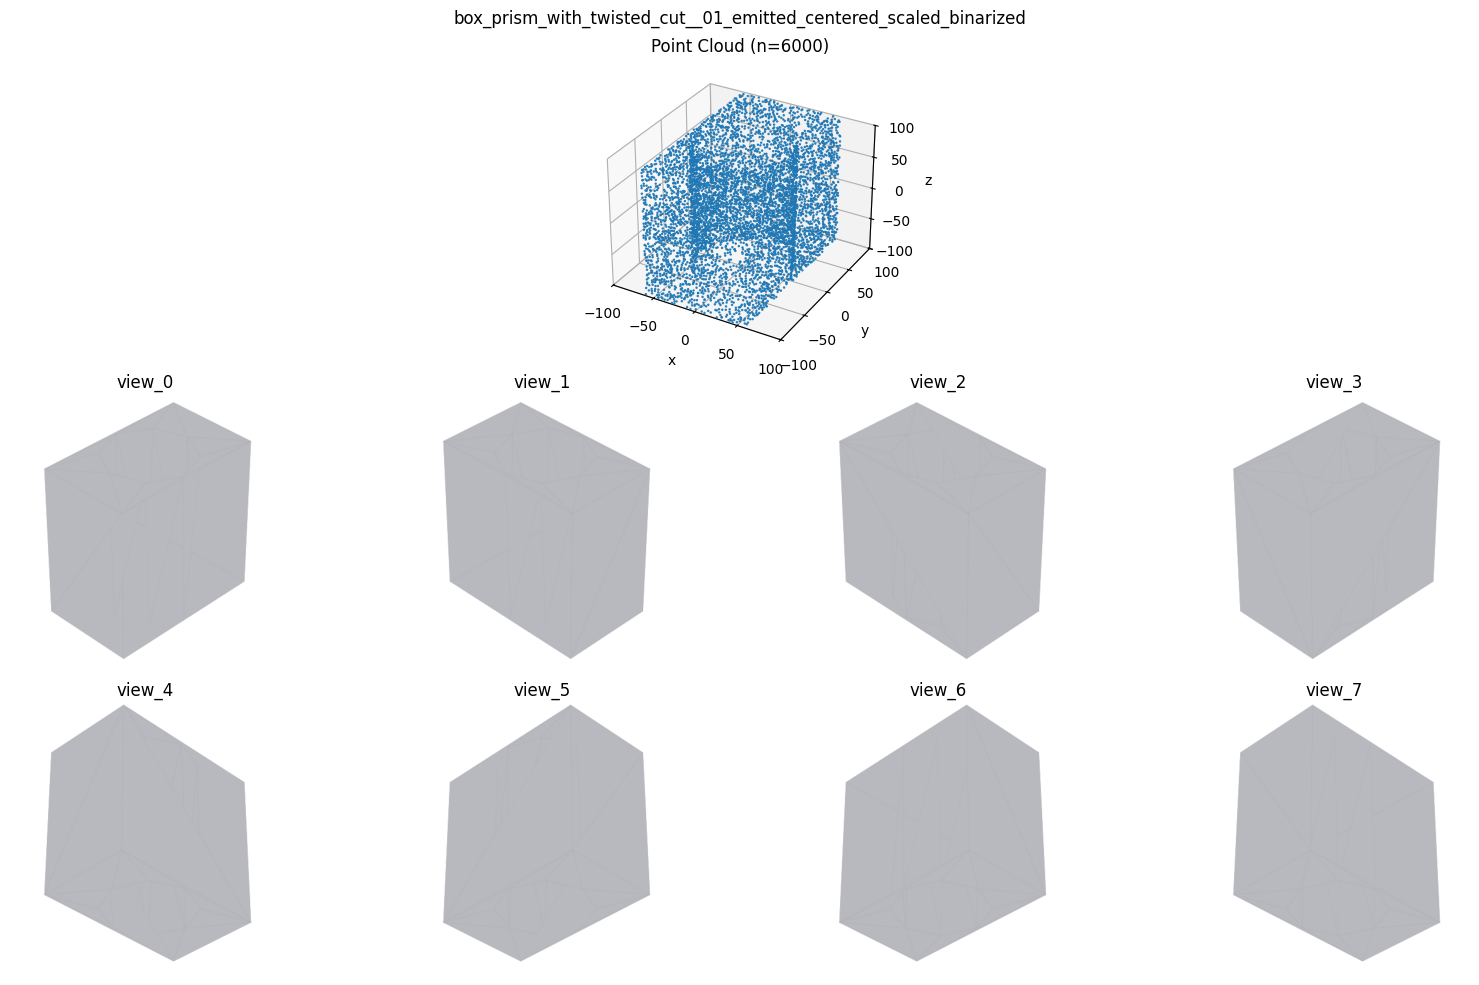

Sample: annular_ring_split_clamp_with_louvered_gusset_spokes__02_emitted_centered_scaled_binarized_centered_scaled_binarized
Code : /home/nicksung/Desktop/nicksung/multimodel_class/cadevolve_data/CADEvolve-C/CADEvolve-C-core/annular_ring_split_clamp_with_louvered_gusset_spokes__02_emitted_centered_scaled_binarized_centered_scaled_binarized.py
PC   : /home/nicksung/Desktop/nicksung/multimodel_class/cadevolve_data/CADEvolve-C_pointcloud/CADEvolve-C/CADEvolve-C-core/annular_ring_split_clamp_with_louvered_gusset_spokes__02_emitted_centered_scaled_binarized_centered_scaled_binarized.npy
Image: /home/nicksung/Desktop/nicksung/multimodel_class/cadevolve_data/CADEvolve-C_image/CADEvolve-C/CADEvolve-C-core/annular_ring_split_clamp_with_louvered_gusset_spokes__02_emitted_centered_scaled_binarized_centered_scaled_binarized
--- CAD Code Preview ---
import cadquery as cq
wp1 = cq.Workplane('XY', origin=(-1, -4, -8))
wp2 = wp1.circle(99)
wp3 = wp2.circle(94)
wp4 = wp3.extrude(14)
wp5 = cq.Workplane(

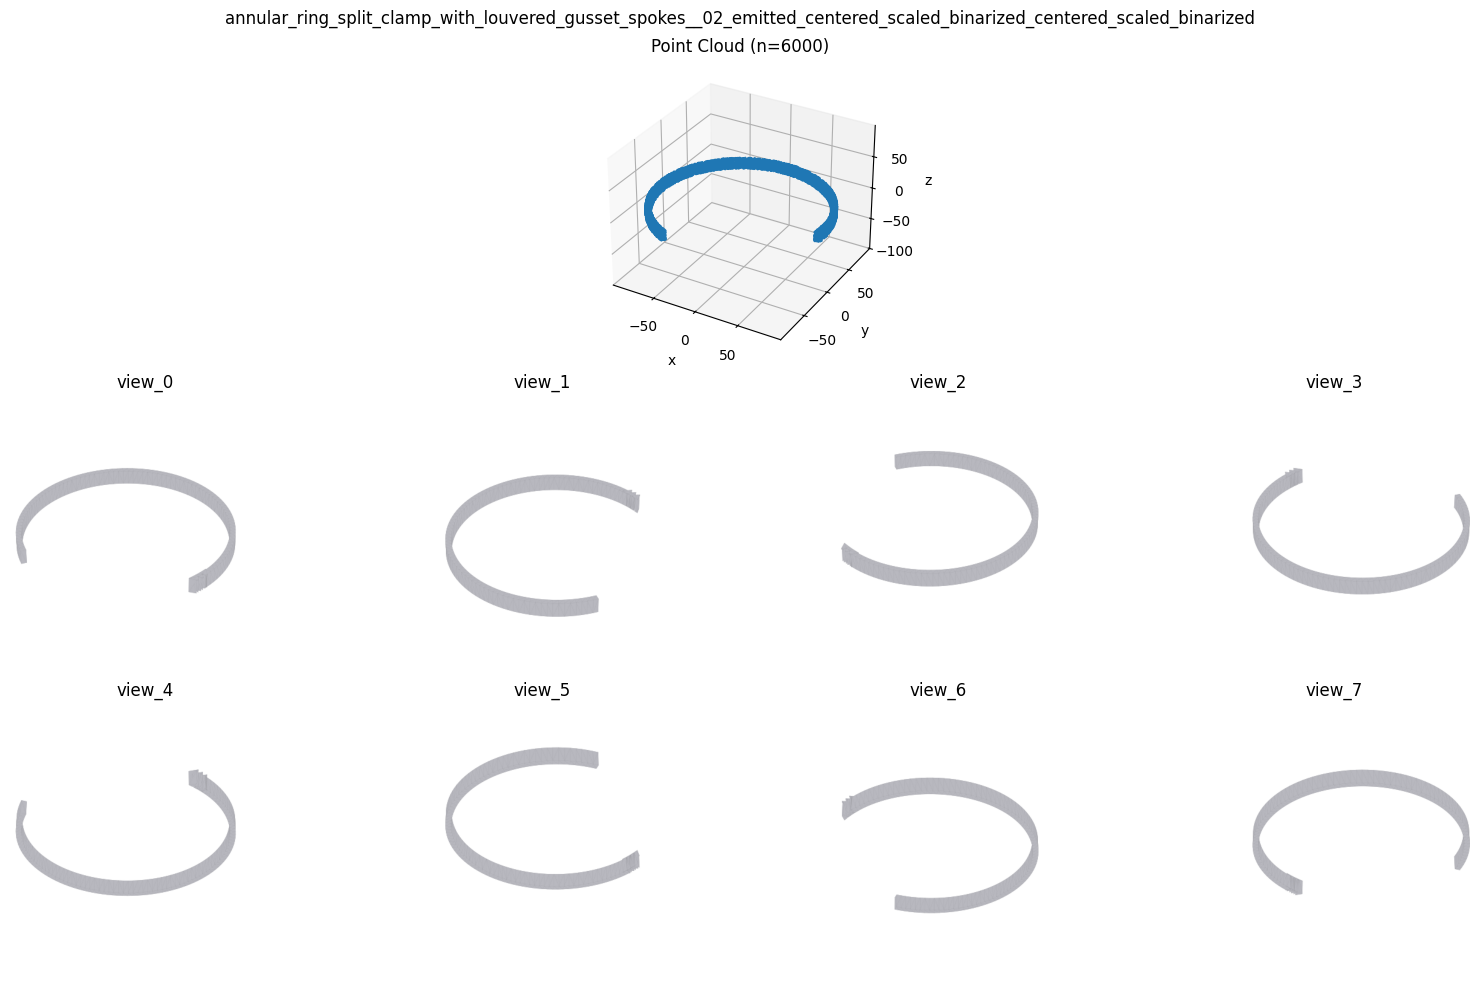

Sample: cylinder_with_recessed_cooling_fins__07_emitted_centered_scaled_binarized
Code : /home/nicksung/Desktop/nicksung/multimodel_class/cadevolve_data/CADEvolve-C/CADEvolve-C-core/cylinder_with_recessed_cooling_fins__07_emitted_centered_scaled_binarized.py
PC   : /home/nicksung/Desktop/nicksung/multimodel_class/cadevolve_data/CADEvolve-C_pointcloud/CADEvolve-C/CADEvolve-C-core/cylinder_with_recessed_cooling_fins__07_emitted_centered_scaled_binarized.npy
Image: /home/nicksung/Desktop/nicksung/multimodel_class/cadevolve_data/CADEvolve-C_image/CADEvolve-C/CADEvolve-C-core/cylinder_with_recessed_cooling_fins__07_emitted_centered_scaled_binarized
--- CAD Code Preview ---
import cadquery as cq
wp1 = cq.Workplane('XY', origin=(0, 0, -100))
wp2 = wp1.circle(94)
wp3 = wp2.extrude(200)
wp4 = wp3.faces('>Z')
wp5 = wp4.workplane()
wp6 = wp5.circle(64)
wp7 = wp6.cutThruAll()
wp8 = cq.Workplane('XY', origin=(0, 0, -100))
wp9 = wp8.workplane(offset=26)
wp10 = wp9.circle(94)
wp11 = wp10.circle(89)
w

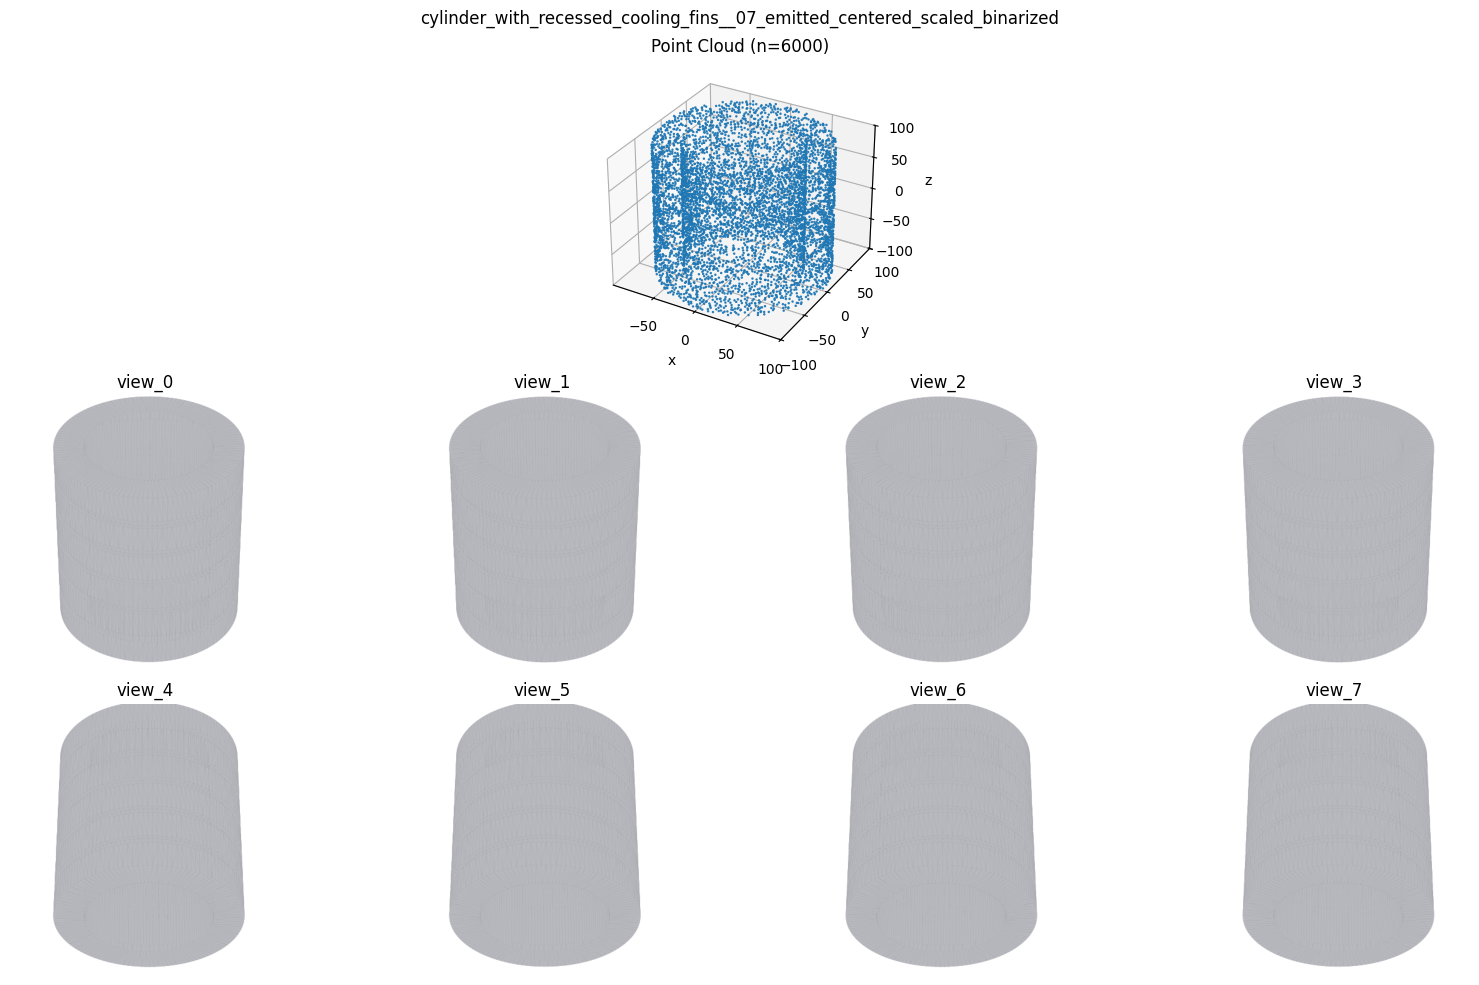

Sample: cylinder_radial_spoke_cutouts_with_annular_ribs__08_emitted_centered_scaled_binarized
Code : /home/nicksung/Desktop/nicksung/multimodel_class/cadevolve_data/CADEvolve-C/CADEvolve-C-core/cylinder_radial_spoke_cutouts_with_annular_ribs__08_emitted_centered_scaled_binarized.py
PC   : /home/nicksung/Desktop/nicksung/multimodel_class/cadevolve_data/CADEvolve-C_pointcloud/CADEvolve-C/CADEvolve-C-core/cylinder_radial_spoke_cutouts_with_annular_ribs__08_emitted_centered_scaled_binarized.npy
Image: /home/nicksung/Desktop/nicksung/multimodel_class/cadevolve_data/CADEvolve-C_image/CADEvolve-C/CADEvolve-C-core/cylinder_radial_spoke_cutouts_with_annular_ribs__08_emitted_centered_scaled_binarized
--- CAD Code Preview ---
import cadquery as cq
wp1 = cq.Workplane('XY', origin=(141, -24, -100))
wp2 = wp1.circle(149)
wp3 = wp2.circle(141)
wp4 = wp3.extrude(200)
wp5 = cq.Workplane('XY', origin=(141, -24, -100))
wp6 = wp5.polyline([[141, -3], [149, -3], [149, 3], [141, 3]])
wp7 = wp6.close()
wp8 =

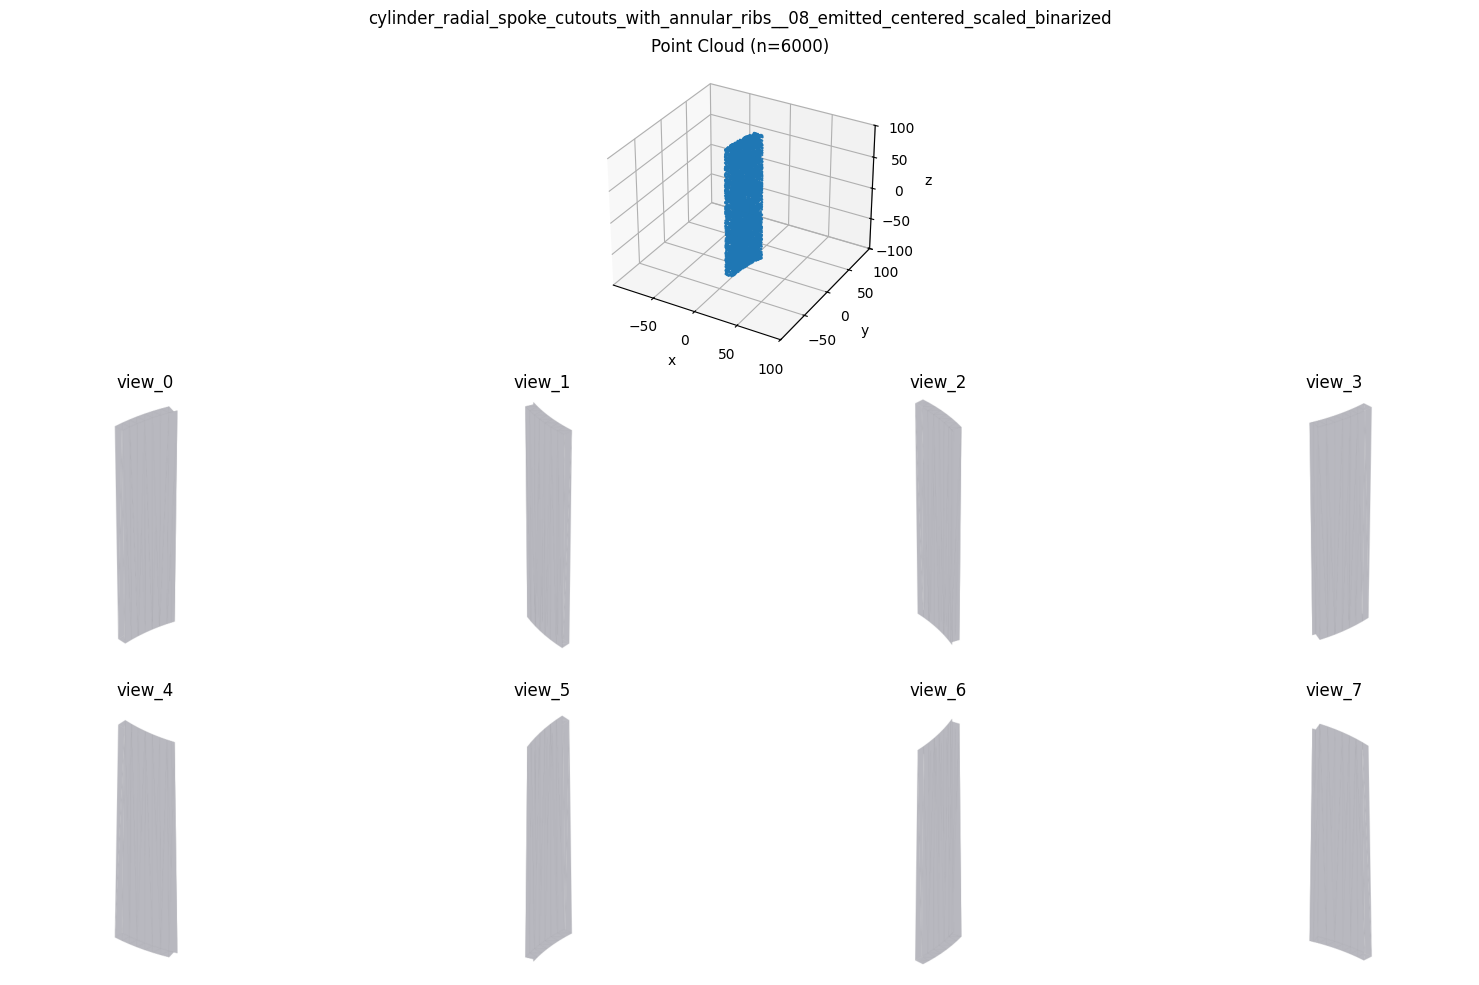

Sample: cylinder_basic_with_spoked_ring__08_emitted_centered_scaled_binarized
Code : /home/nicksung/Desktop/nicksung/multimodel_class/cadevolve_data/CADEvolve-C/CADEvolve-C-core/cylinder_basic_with_spoked_ring__08_emitted_centered_scaled_binarized.py
PC   : /home/nicksung/Desktop/nicksung/multimodel_class/cadevolve_data/CADEvolve-C_pointcloud/CADEvolve-C/CADEvolve-C-core/cylinder_basic_with_spoked_ring__08_emitted_centered_scaled_binarized.npy
Image: /home/nicksung/Desktop/nicksung/multimodel_class/cadevolve_data/CADEvolve-C_image/CADEvolve-C/CADEvolve-C-core/cylinder_basic_with_spoked_ring__08_emitted_centered_scaled_binarized
--- CAD Code Preview ---
import cadquery as cq
wp1 = cq.Workplane('XY', origin=(0, 0, -38))
wp2 = wp1.circle(93)
wp3 = wp2.extrude(76)
wp4 = cq.Workplane('XY', origin=(0, 0, -38))
wp5 = wp4.transformed(offset=[0, 0, 21])
wp6 = wp5.circle(100)
wp7 = wp6.circle(93)
wp8 = wp7.extrude(35)
wp9 = wp3.union(wp8)
wp10 = cq.Workplane('XY', origin=(0, 0, -38))
wp11 = wp10

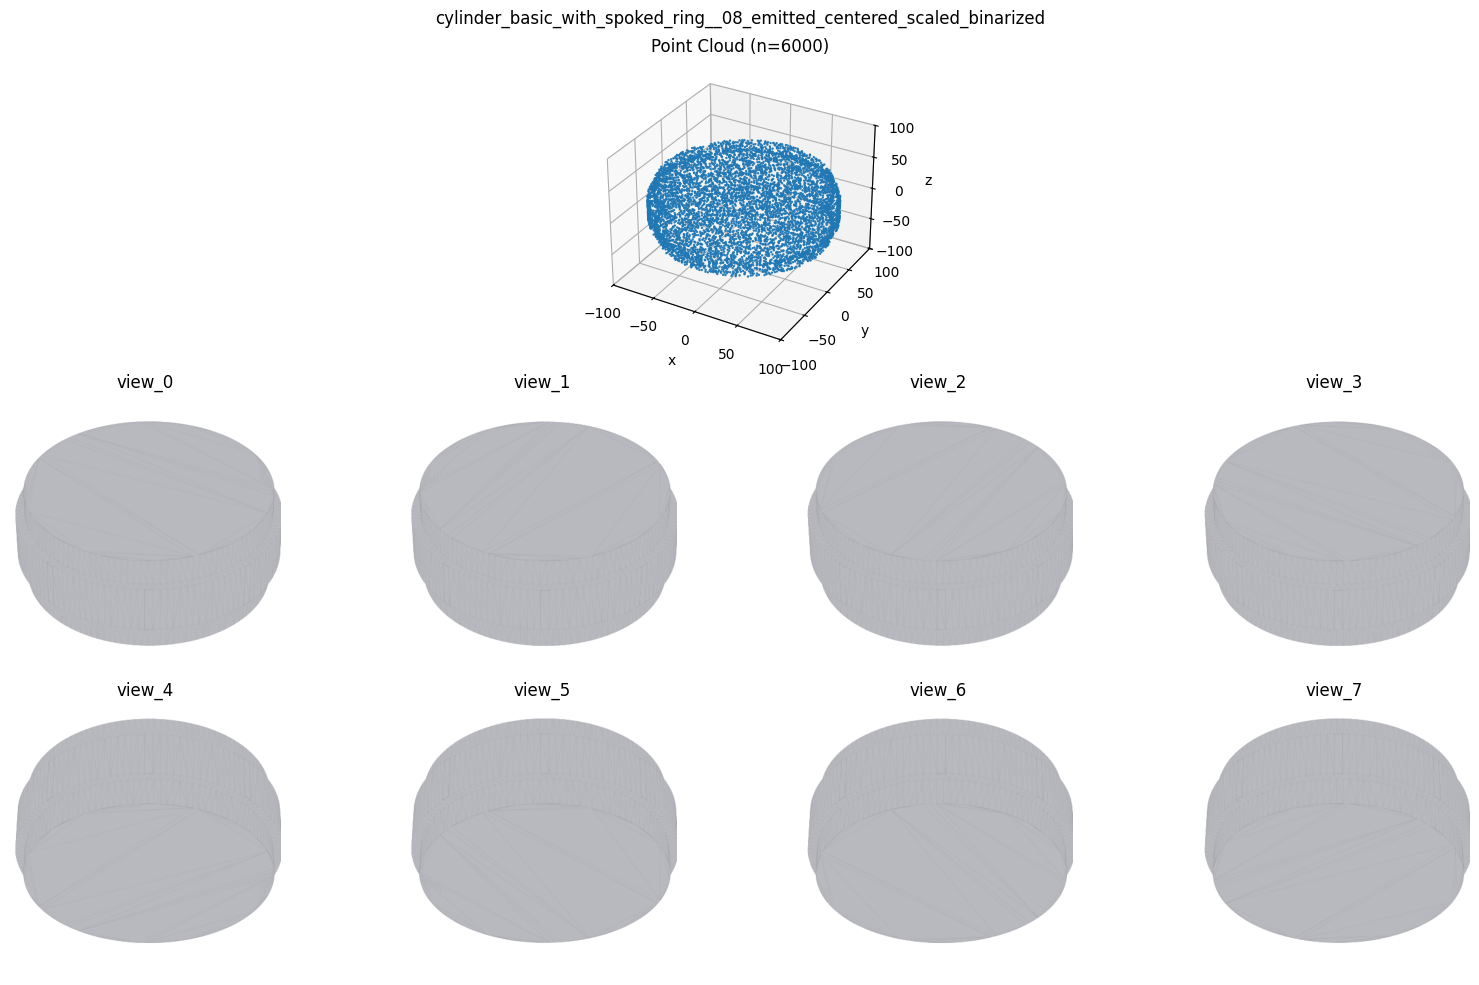

In [6]:
# Pick more sets to visualize
NUM_SAMPLES = 6
RANDOM_SEED = 42

assert len(samples) > 0, 'No matched samples found. Check dataset paths.'

random.seed(RANDOM_SEED)
chosen = random.sample(samples, k=min(NUM_SAMPLES, len(samples)))

for s in chosen:
    show_sample(s)

Sample: clamp_rib_annular_bridge_with_reinforcing_gussets_and_snap_tabs__04_emitted_centered_scaled_binarized
Code : /home/nicksung/Desktop/nicksung/multimodel_class/cadevolve_data/CADEvolve-C/CADEvolve-C-core/clamp_rib_annular_bridge_with_reinforcing_gussets_and_snap_tabs__04_emitted_centered_scaled_binarized.py
PC   : /home/nicksung/Desktop/nicksung/multimodel_class/cadevolve_data/CADEvolve-C_pointcloud/CADEvolve-C/CADEvolve-C-core/clamp_rib_annular_bridge_with_reinforcing_gussets_and_snap_tabs__04_emitted_centered_scaled_binarized.npy
Image: /home/nicksung/Desktop/nicksung/multimodel_class/cadevolve_data/CADEvolve-C_image/CADEvolve-C/CADEvolve-C-core/clamp_rib_annular_bridge_with_reinforcing_gussets_and_snap_tabs__04_emitted_centered_scaled_binarized
--- CAD Code Preview ---
import cadquery as cq
wp1 = cq.Workplane('XY', origin=(-139, -100, -43))
wp2 = wp1.moveTo(204, 0)
wp3 = wp2.threePointArc([164, 122], [60, 196])
wp4 = wp3.lineTo(43, 140)
wp5 = wp4.threePointArc([118, 87], [146,

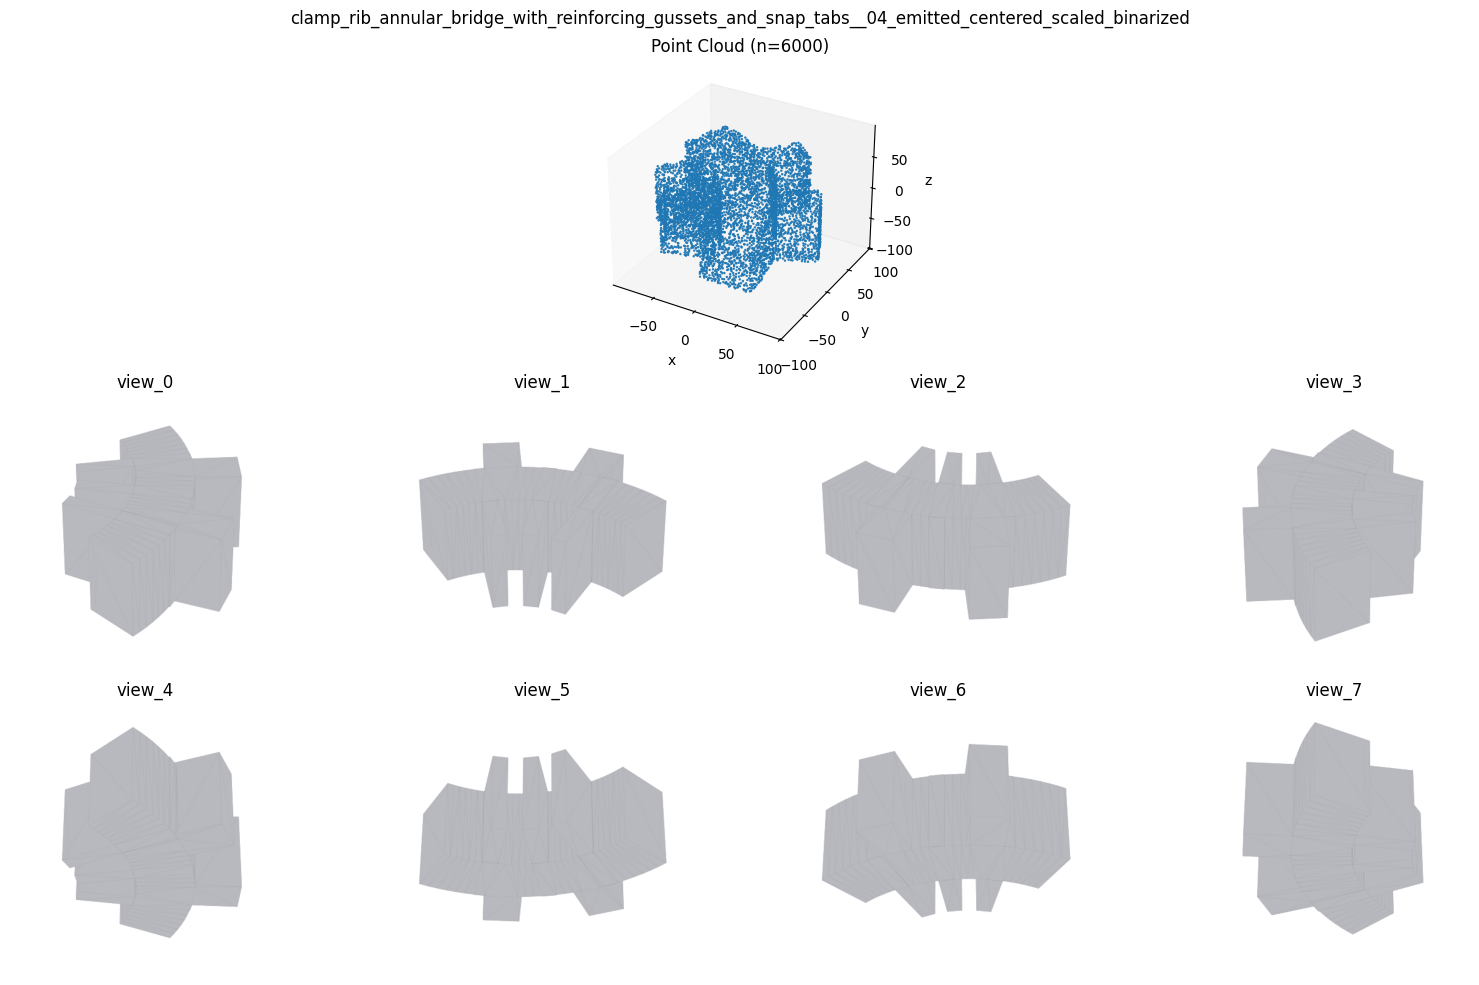

In [10]:
# Visualize a specific sample requested by name
TARGET_SAMPLE = 'clamp_rib_annular_bridge_with_reinforcing_gussets_and_snap_tabs__04_emitted_centered_scaled_binarized'

name_to_sample = {s['name']: s for s in samples}

if TARGET_SAMPLE in name_to_sample:
    show_sample(name_to_sample[TARGET_SAMPLE])
else:
    print('Missing sample:', TARGET_SAMPLE)

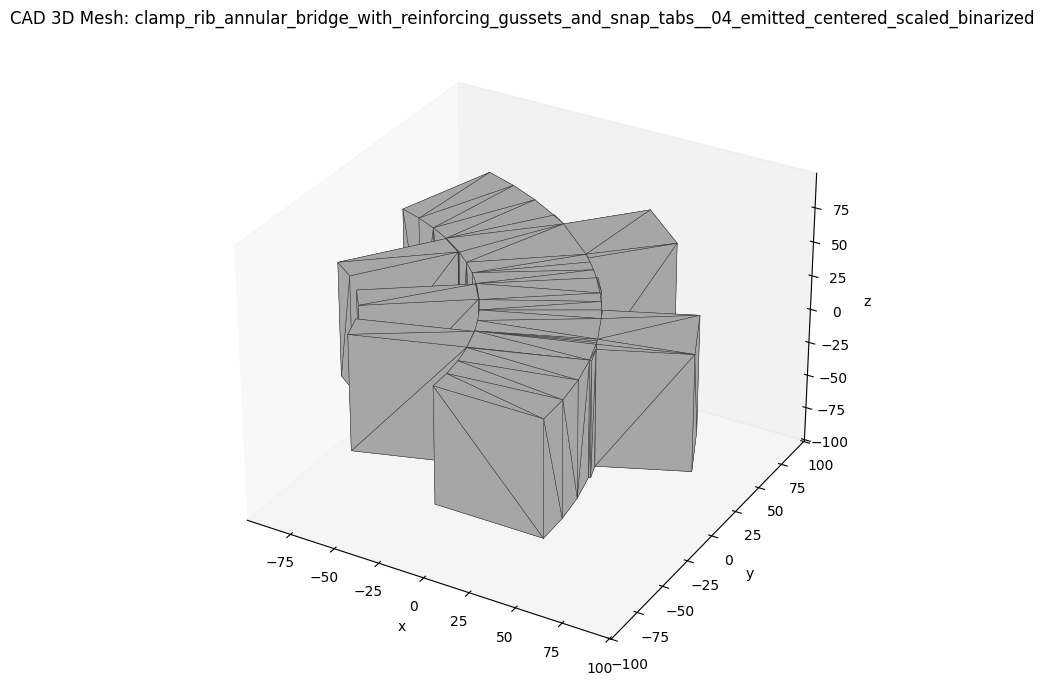

In [11]:
# Render the actual 3D CAD geometry for TARGET_SAMPLE from its .py file
import cadquery as cq
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


def _set_axes_equal(ax, vertices: np.ndarray):
    mins = vertices.min(axis=0)
    maxs = vertices.max(axis=0)
    center = (mins + maxs) / 2
    radius = (maxs - mins).max() / 2
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)


if TARGET_SAMPLE in name_to_sample:
    sample = name_to_sample[TARGET_SAMPLE]
    code_text = sample['code_path'].read_text(encoding='utf-8', errors='replace')

    ns = {'cq': cq}
    exec(compile(code_text, str(sample['code_path']), 'exec'), ns)

    cad_obj = ns.get('result', None)
    if cad_obj is None:
        raise ValueError("Sample script did not define variable 'result'.")

    shape = cad_obj.val() if hasattr(cad_obj, 'val') else cad_obj

    verts, faces = shape.tessellate(0.8, 0.2)
    vertices = np.array([[v.x, v.y, v.z] for v in verts], dtype=float)
    triangles = np.array(faces, dtype=int)

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')

    mesh = Poly3DCollection(vertices[triangles], alpha=1.0)
    mesh.set_facecolor((0.65, 0.65, 0.65, 1.0))
    mesh.set_edgecolor((0.22, 0.22, 0.22, 0.95))
    mesh.set_linewidth(0.35)
    ax.add_collection3d(mesh)

    _set_axes_equal(ax, vertices)
    ax.grid(False)
    ax.set_title(f'CAD 3D Mesh: {TARGET_SAMPLE}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    plt.tight_layout()
    plt.show()
else:
    print('Missing sample:', TARGET_SAMPLE)